In [19]:
# 1. Cài thư viện
library(dplyr)
library(stringr)
library(ggplot2)
library(tidyr)
library(GGally)

In [20]:
# 2. Load dữ liệu
#path tới dữ liệu có thể khác tùy vào môi trường và folder mình đặt file dữ liệu/code
path <-"/kaggle/input/datasets/iliassekkaf/computerparts/All_GPUs.csv"
gpu_raw <- read.csv(path, stringsAsFactors = FALSE)
names(gpu_raw)
length(names(gpu_raw))

[1] "Architecture"           "Best_Resolution"        "Boost_Clock"           
 [4] "Core_Speed"             "DVI_Connection"         "Dedicated"             
 [7] "Direct_X"               "DisplayPort_Connection" "HDMI_Connection"       
[10] "Integrated"             "L2_Cache"               "Manufacturer"          
[13] "Max_Power"              "Memory"                 "Memory_Bandwidth"      
[16] "Memory_Bus"             "Memory_Speed"           "Memory_Type"           
[19] "Name"                   "Notebook_GPU"           "Open_GL"               
[22] "PSU"                    "Pixel_Rate"             "Power_Connector"       
[25] "Process"                "ROPs"                   "Release_Date"          
[28] "Release_Price"          "Resolution_WxH"         "SLI_Crossfire"         
[31] "Shader"                 "TMUs"                   "Texture_Rate"          
[34] "VGA_Connection"

[1] 34

In [21]:
# 3. Chọn dữ liệu quan trọng
# Chọn 12 biến quan trọng nhất để phân tích
cols_to_keep <- c("Manufacturer", "Core_Speed", "Max_Power", "Memory_Type", 
                  "Memory", "Memory_Bandwidth", "Memory_Speed", "Memory_Bus", 
                  "Process", "ROPs", "TMUs", "Notebook_GPU")

gpu_data <- gpu_raw %>% select(all_of(cols_to_keep))
head(gpu_data)

,Manufacturer,Core_Speed,Max_Power,Memory_Type,Memory,Memory_Bandwidth,Memory_Speed,Memory_Bus,Process,ROPs,TMUs,Notebook_GPU
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,Nvidia,738 MHz,141 Watts,GDDR3,1024 MB,64GB/sec,1000 MHz,256 Bit,55nm,16,64,No
2,AMD,-,215 Watts,GDDR3,512 MB,106GB/sec,828 MHz,512 Bit,80nm,16,16,No
3,AMD,-,200 Watts,GDDR3,512 MB,51.2GB/sec,800 MHz,256 Bit,80nm,16,16,No
4,AMD,-,,GDDR4,256 MB,36.8GB/sec,1150 MHz,128 Bit,65nm,4,8,No
5,AMD,-,45 Watts,GDDR3,256 MB,22.4GB/sec,700 MHz,128 Bit,65nm,4,8,No
6,AMD,-,50 Watts,GDDR4,256 MB,35.2GB/sec,1100 MHz,128 Bit,65nm,4,8,No


In [22]:
gpu_data[] <- lapply(gpu_data, function(x) gsub("^\\n- $", NA, x))
head(gpu_data)

,Manufacturer,Core_Speed,Max_Power,Memory_Type,Memory,Memory_Bandwidth,Memory_Speed,Memory_Bus,Process,ROPs,TMUs,Notebook_GPU
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Nvidia,738 MHz,141 Watts,GDDR3,1024 MB,64GB/sec,1000 MHz,256 Bit,55nm,16,64,No
2,AMD,NA,215 Watts,GDDR3,512 MB,106GB/sec,828 MHz,512 Bit,80nm,16,16,No
3,AMD,NA,200 Watts,GDDR3,512 MB,51.2GB/sec,800 MHz,256 Bit,80nm,16,16,No
4,AMD,NA,,GDDR4,256 MB,36.8GB/sec,1150 MHz,128 Bit,65nm,4,8,No
5,AMD,NA,45 Watts,GDDR3,256 MB,22.4GB/sec,700 MHz,128 Bit,65nm,4,8,No
6,AMD,NA,50 Watts,GDDR4,256 MB,35.2GB/sec,1100 MHz,128 Bit,65nm,4,8,No


In [23]:
process_multiplier <- function(column) {
  column <- as.character(column)
  
  base_val <- as.numeric(str_extract(column, "\\d+"))
  
  mult_raw <- str_extract(column, "(?i)x[^0-9]*\\d+")
  
  mult <- as.numeric(str_extract(mult_raw, "\\d+"))
  
  mult[is.na(mult)] <- 1
  
  return(base_val * mult)
}

In [24]:

# 4. lam sach du lieu
gpu_clean <- gpu_data %>%
  mutate(
    # Xóa đơn vị và chuyển thành numeric
    Core_Speed = as.numeric(str_remove(Core_Speed, " MHz")),
    Max_Power = as.numeric(str_remove(Max_Power, " Watts")),
    Memory = as.numeric(str_remove(Memory, " MB")),
    Memory_Speed = as.numeric(str_remove(Memory_Speed, " MHz")),
    Memory_Bus = as.numeric(str_remove(Memory_Bus, " Bit")),
    Process = as.numeric(str_remove(Process, "nm")),
    TMUs = as.numeric(str_extract(as.character(TMUs), "[\\d\\.]+")),
    # Xử lý Bandwidth: Nếu là MB/sec thì đổi ra GB/sec (/1000)
    Memory_Bandwidth = ifelse(str_detect(Memory_Bandwidth, "MB/sec"),
                              as.numeric(str_extract(Memory_Bandwidth, "[\\d\\.]+")) / 1000,
                              as.numeric(str_extract(Memory_Bandwidth, "[\\d\\.]+"))),
    
    # Xử lý ROPs
    ROPs = process_multiplier(ROPs),
      
    # Chuẩn hóa các chuỗi rỗng hoặc "\n-" thành NA
    Manufacturer = ifelse(Manufacturer %in% c("", "\n-", " "), NA, trimws(Manufacturer)),
    Memory_Type = ifelse(Memory_Type %in% c("", "\n-", " "), NA, trimws(Memory_Type)),
    
    # Chuyển Notebook_GPU thành Boolean (TRUE/FALSE)
    Notebook_GPU = ifelse(Notebook_GPU == "Yes", TRUE, FALSE)
  ) %>%
  filter(Manufacturer %in% c("Nvidia", "AMD", "Intel", "ATI"))

head(gpu_clean)

,Manufacturer,Core_Speed,Max_Power,Memory_Type,Memory,Memory_Bandwidth,Memory_Speed,Memory_Bus,Process,ROPs,TMUs,Notebook_GPU
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,Nvidia,738,141,GDDR3,1024,64.0,1000,256,55,16,64,FALSE
2,AMD,NA,215,GDDR3,512,106.0,828,512,80,16,16,FALSE
3,AMD,NA,200,GDDR3,512,51.2,800,256,80,16,16,FALSE
4,AMD,NA,NA,GDDR4,256,36.8,1150,128,65,4,8,FALSE
5,AMD,NA,45,GDDR3,256,22.4,700,128,65,4,8,FALSE
6,AMD,NA,50,GDDR4,256,35.2,1100,128,65,4,8,FALSE


In [25]:
# 5. XXử lí dữ liệu khuyết thiếu

na_summary <- data.frame(
  Variable = names(gpu_clean),
  Missing_Count = colSums(is.na(gpu_clean)),
  Missing_Percentage = round(colMeans(is.na(gpu_clean)) * 100, 2)
)

cat("\n--- BẢNG TÓM TẮT DỮ LIỆU KHUYẾT THIẾU ---\n")
print(na_summary)



--- BẢNG TÓM TẮT DỮ LIỆU KHUYẾT THIẾU ---
                         Variable Missing_Count Missing_Percentage
Manufacturer         Manufacturer             0               0.00
Core_Speed             Core_Speed           936              27.48
Max_Power               Max_Power           625              18.35
Memory_Type           Memory_Type            56               1.64
Memory                     Memory           420              12.33
Memory_Bandwidth Memory_Bandwidth           121               3.55
Memory_Speed         Memory_Speed           105               3.08
Memory_Bus             Memory_Bus            62               1.82
Process                   Process           463              13.59
ROPs                         ROPs           538              15.80
TMUs                         TMUs           538              15.80
Notebook_GPU         Notebook_GPU             0               0.00


In [26]:
# Dựa vào bảng na_summary ở trên, nhóm đưa ra chiến lược xử lý như sau:
# 1. Nhóm biến Memory_Bandwidth, Memory_Bus ... có tỷ lệ khuyết cực thấp 
#    => Xóa các dòng khuyết (Drop NA) để giữ tính chân thực của dữ liệu mục tiêu.
# 2. Nhóm biến Core_Speed, Process, Memory_Speed... có tỷ lệ khuyết nhiều
gpu_clean <- gpu_clean %>%
  drop_na(Memory_Type, Memory_Bus, Memory_Speed, Memory_Bandwidth)

# 2. Fill Median cho Nhóm 3 (Các biến độc lập khuyết nhiều)
gpu_clean <- gpu_clean %>%
  mutate(
    Core_Speed = ifelse(is.na(Core_Speed), median(Core_Speed, na.rm = TRUE), Core_Speed),
    Memory = ifelse(is.na(Memory), median(Memory, na.rm = TRUE), Memory),
    Process = ifelse(is.na(Process), median(Process, na.rm = TRUE), Process),
    ROPs = ifelse(is.na(ROPs), median(ROPs, na.rm = TRUE), ROPs),
    TMUs = ifelse(is.na(TMUs), median(TMUs, na.rm = TRUE), TMUs),
    Max_Power = ifelse(is.na(Max_Power), median(Max_Power, na.rm = TRUE), Max_Power)
  )
# Kiểm tra lại chắc chắn đã hết NA chưa
print(colSums(is.na(gpu_clean)))



    Manufacturer       Core_Speed        Max_Power      Memory_Type 
               0                0                0                0 
          Memory Memory_Bandwidth     Memory_Speed       Memory_Bus 
               0                0                0                0 
         Process             ROPs             TMUs     Notebook_GPU 
               0                0                0                0 


In [27]:
num_ddr <- gpu_clean %>% 
  filter(Memory_Type == "DDR") %>% 
  nrow()

cat("Số lượng dòng có Memory_Type là 'DDR':", num_ddr, "\n")

gpu_clean <- gpu_clean %>%
  filter(Memory_Type != "DDR")

cat("Số lượng dòng còn lại trong tập dữ liệu:", nrow(gpu_clean), "\n")

Số lượng dòng có Memory_Type là 'DDR': 106 
Số lượng dòng còn lại trong tập dữ liệu: 3179 


In [28]:
# (Tùy chọn) Ghi đè ra file CSV cuối cùng để xài cho các bước sau
write.csv(gpu_clean, "gpu_ready_for_models.csv", row.names = FALSE)

 Manufacturer         Core_Speed       Max_Power     Memory_Type       
 Length:3179        Min.   : 100.0   Min.   :  1.0   Length:3179       
 Class :character   1st Qu.: 840.0   1st Qu.: 60.0   Class :character  
 Mode  :character   Median : 980.0   Median :106.0   Mode  :character  
                    Mean   : 954.1   Mean   :124.5                     
                    3rd Qu.:1050.0   3rd Qu.:160.0                     
                    Max.   :1784.0   Max.   :780.0                     
     Memory      Memory_Bandwidth  Memory_Speed    Memory_Bus    
 Min.   :   64   Min.   :   2.8   Min.   : 250   Min.   :  32.0  
 1st Qu.: 1024   1st Qu.:  29.9   1st Qu.: 900   1st Qu.: 128.0  
 Median : 2048   Median : 112.0   Median :1200   Median : 128.0  
 Mean   : 2891   Mean   : 141.6   Mean   :1206   Mean   : 209.9  
 3rd Qu.: 4096   3rd Qu.: 201.6   3rd Qu.:1502   3rd Qu.: 256.0  
 Max.   :32000   Max.   :1280.0   Max.   :2127   Max.   :8192.0  
    Process            ROPs       

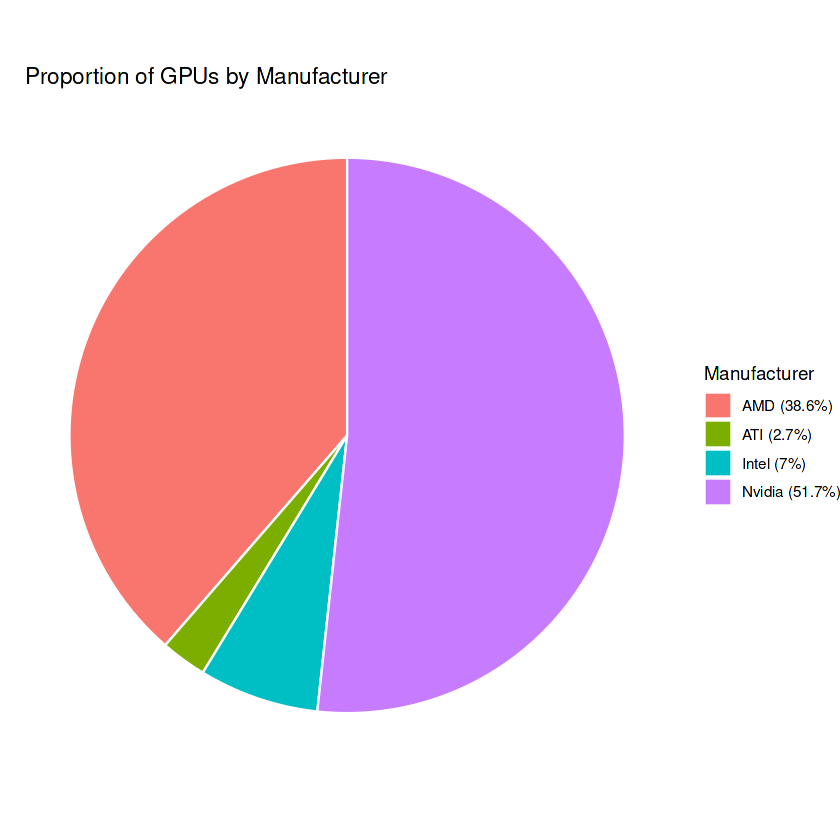

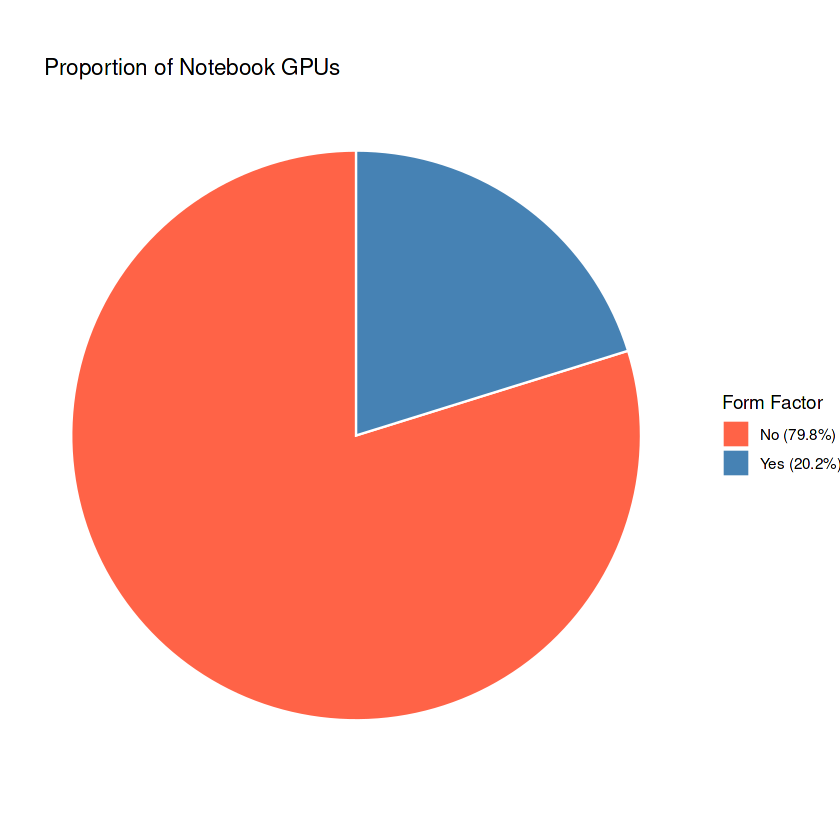

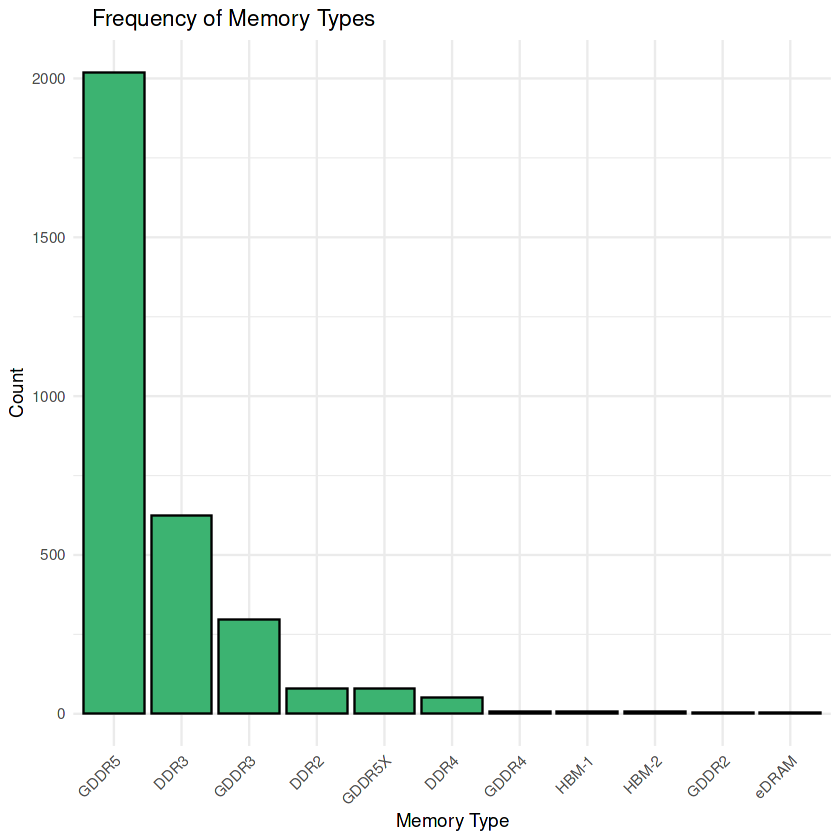

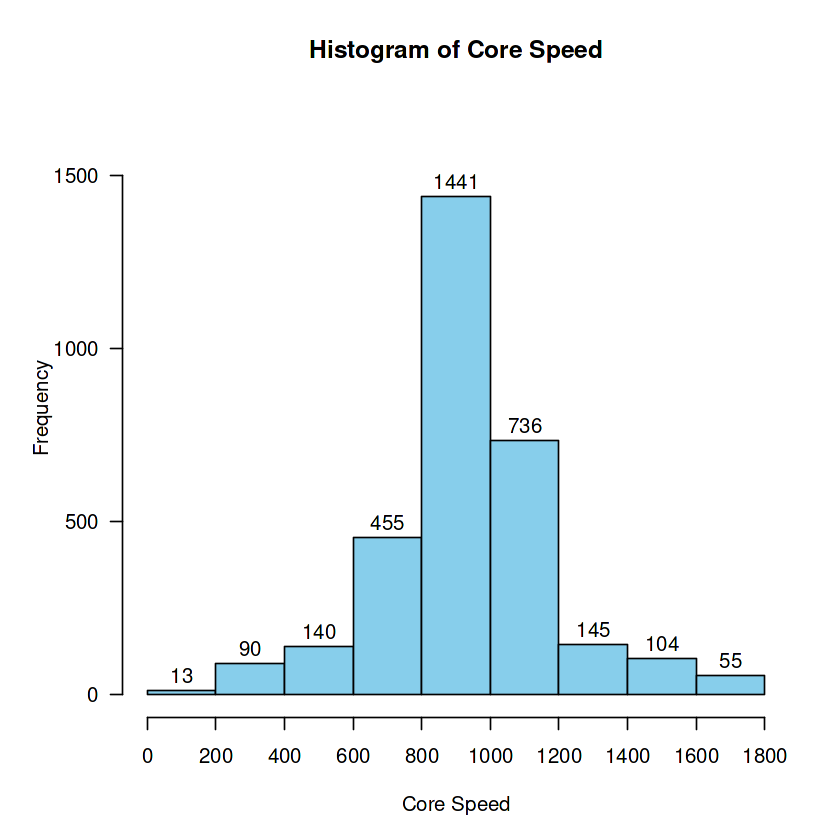

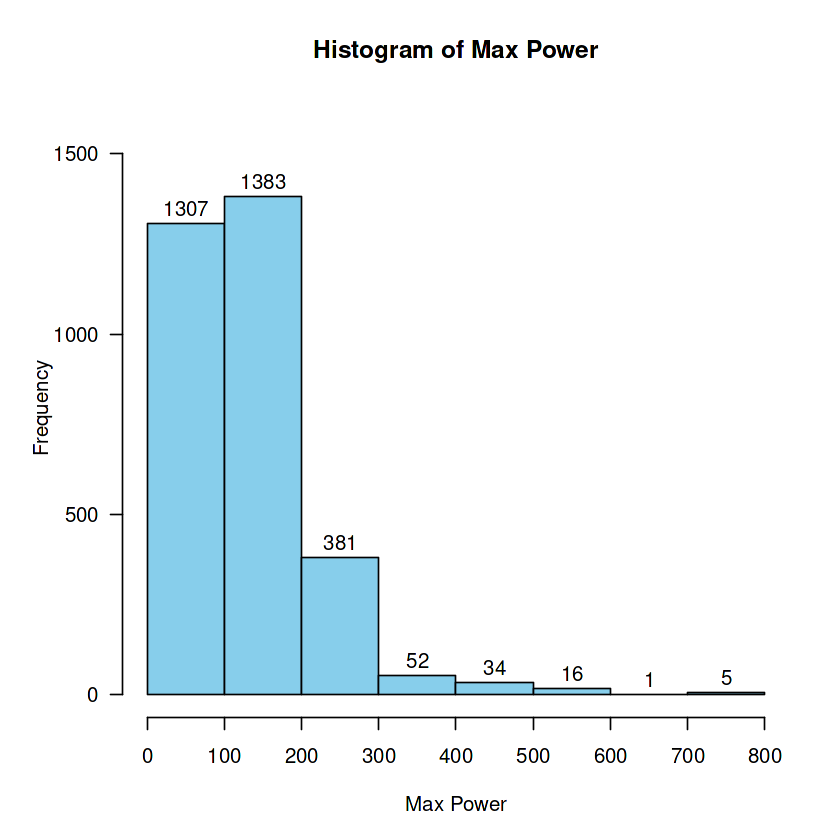

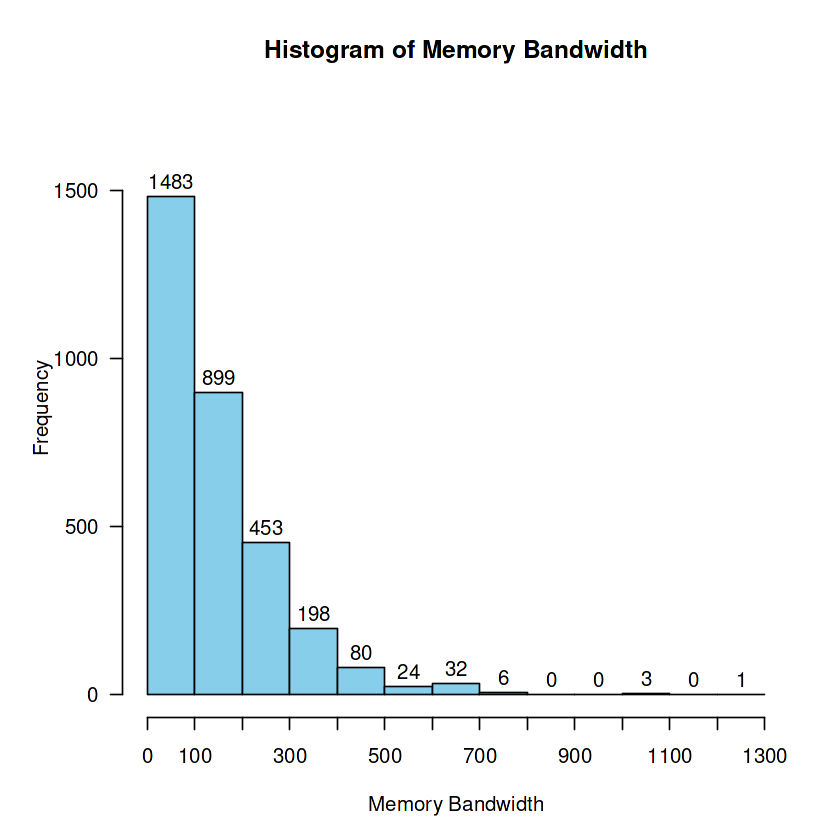

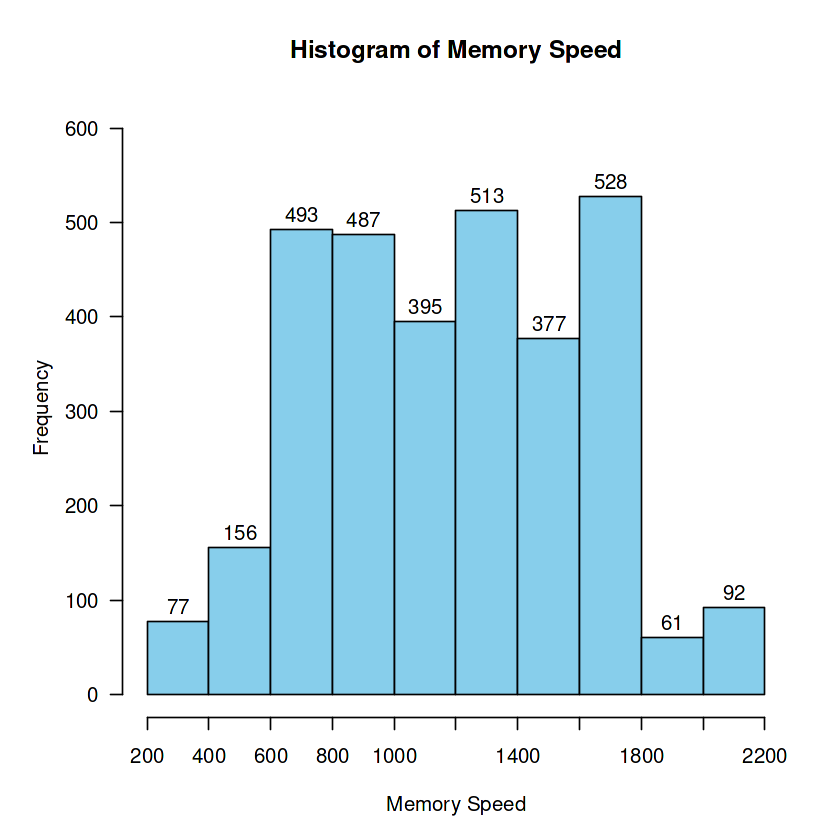

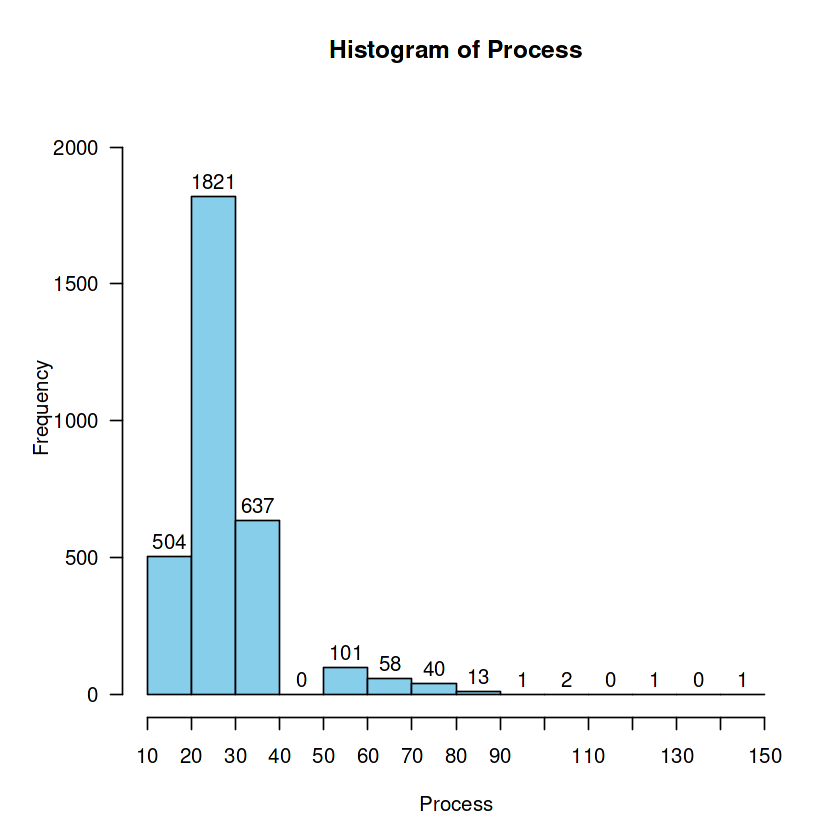

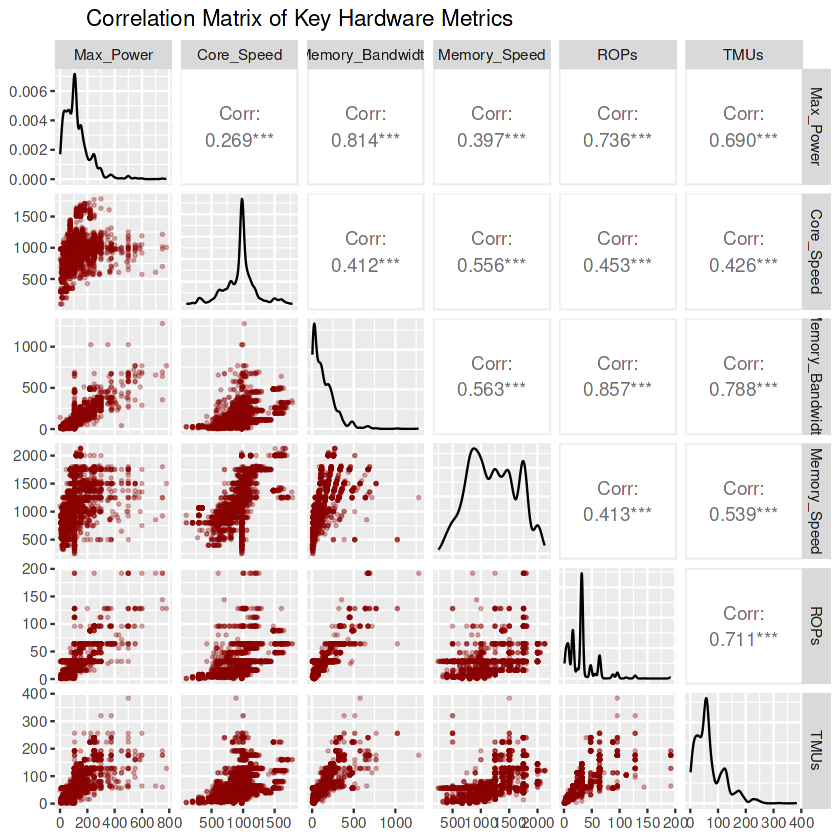

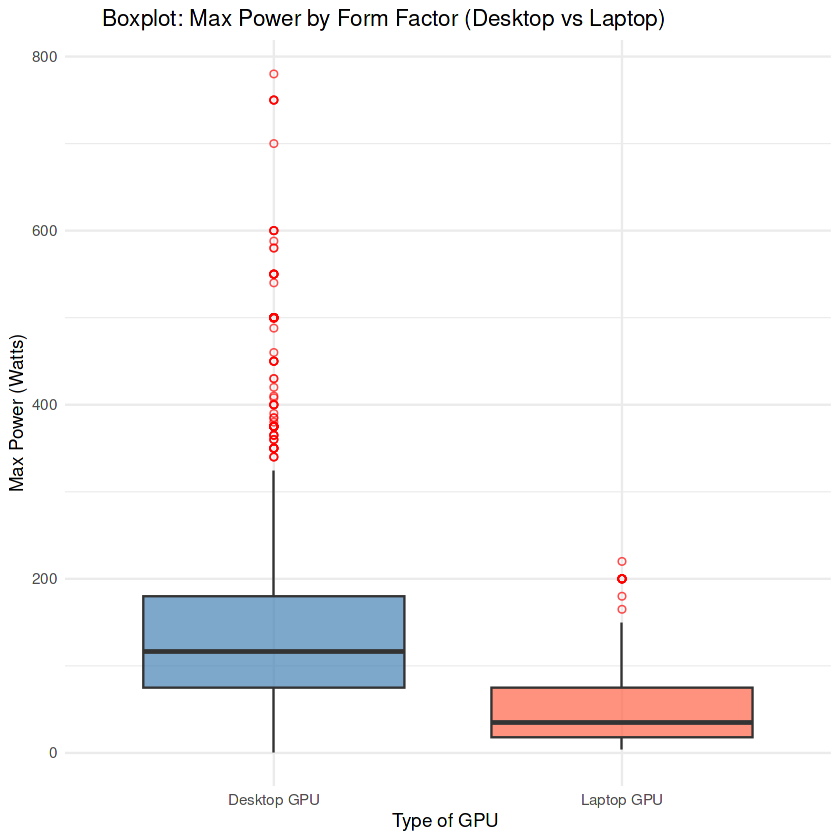

`geom_smooth()` using formula = 'y ~ x'


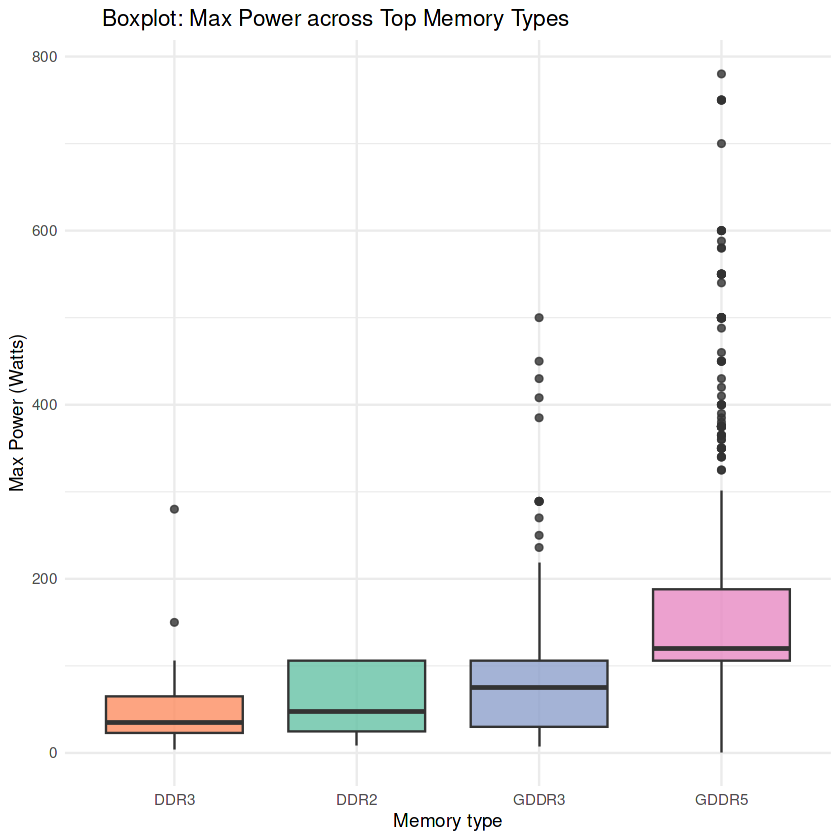

`geom_smooth()` using formula = 'y ~ x'


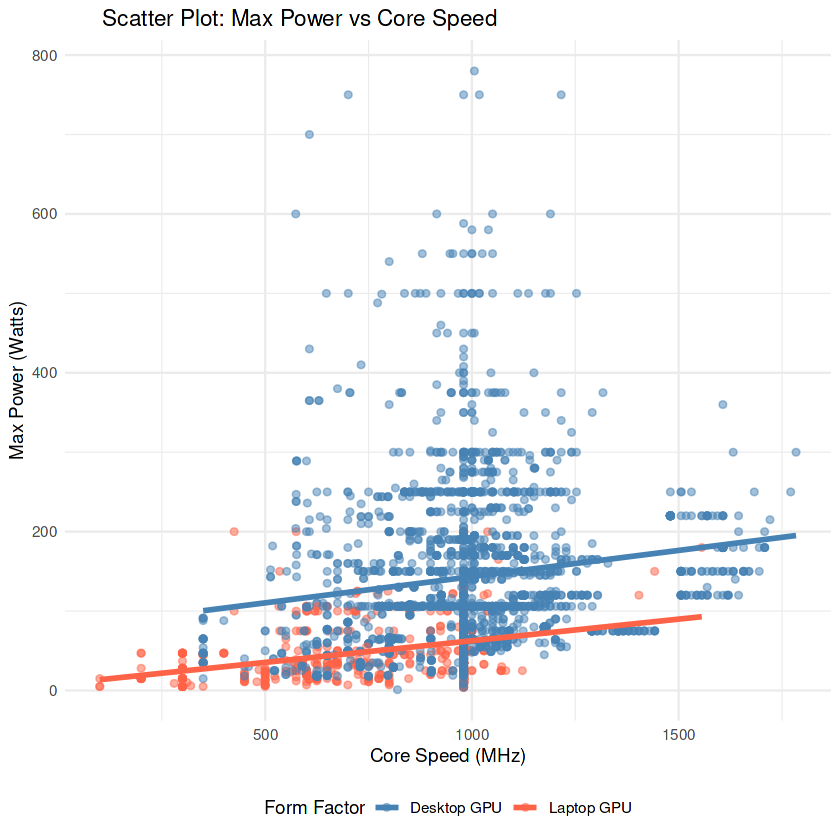

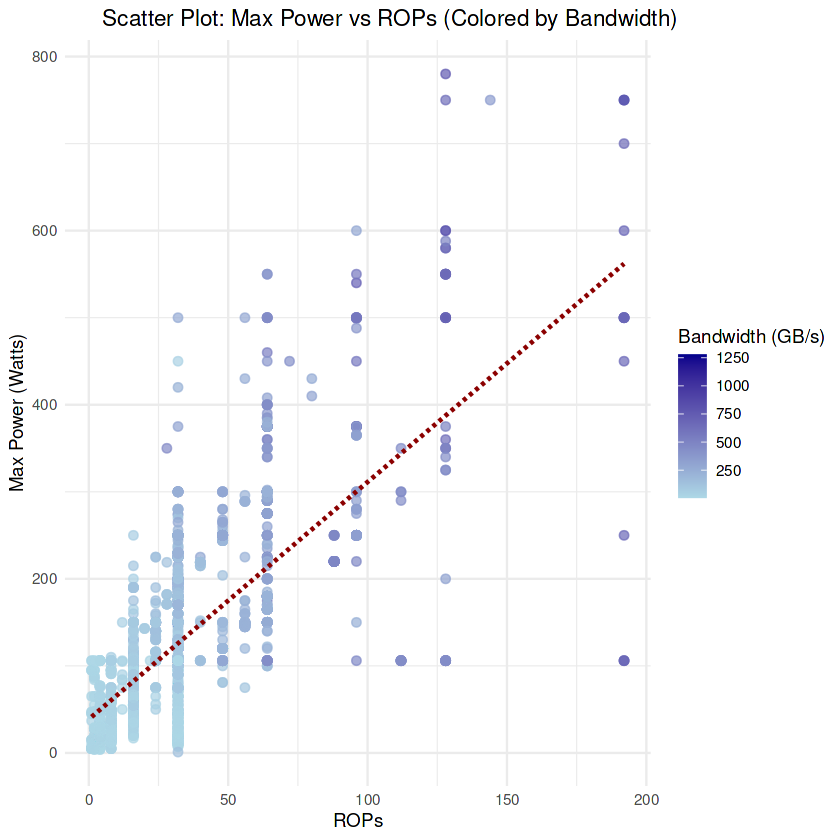

In [29]:

# =========================================================================
# 6. THỐNG KÊ MÔ TẢ VÀ TRỰC QUAN HÓA (EDA)
# =========================================================================

# 6.1 Bảng tóm tắt
summary(gpu_clean)

cat("\n\n")

# 6.2. Vẽ hình

# 1. Pie : manufacturer
pie_manuf <- gpu_clean %>% 
  count(Manufacturer) %>% 
  mutate(prop = n / sum(n) * 100,
         legend_label = paste0(Manufacturer, " (", round(prop, 1), "%)")) %>%
  ggplot(aes(x = "", y = prop, fill = legend_label)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  theme_void() +
  labs(title = "    Proportion of GPUs by Manufacturer", fill = "Manufacturer")

print(pie_manuf)

# 2. Pie Chart: Notebook GPU
pie_notebook <- gpu_clean %>% 
  count(Notebook_GPU) %>% 
  mutate(Type = ifelse(Notebook_GPU, "Yes", "No"),
         prop = n / sum(n) * 100,
         legend_label = paste0(Type, " (", round(prop, 1), "%)")) %>%
  ggplot(aes(x = "", y = prop, fill = legend_label)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  theme_void() +
  scale_fill_manual(values = c("tomato", "steelblue")) +
  labs(title = "       Proportion of Notebook GPUs", fill = "Form Factor")

print(pie_notebook)

# 3. Bar Chart: Memory Type Frequency
bar_memtype <- ggplot(gpu_clean, aes(x = reorder(Memory_Type, Memory_Type, function(x) -length(x)))) +
  geom_bar(fill = "mediumseagreen", color = "black") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "   Frequency of Memory Types", x = "Memory Type", y = "Count")

print(bar_memtype)

#4. Histogram
numeric_vars <- c("Core_Speed", "Max_Power", "Memory_Bandwidth", 
                  "Memory_Speed", "Process")

par(mar = c(5, 5, 4, 2) + 0.1)

for (var in numeric_vars) {
  data_vec <- gpu_clean[[var]]
  
  breaks_vec <- pretty(data_vec, n = 10)
  
  h <- hist(data_vec, breaks = breaks_vec, plot = FALSE)
  
  hist(data_vec, 
       breaks = breaks_vec, 
       col = "skyblue", 
       border = "black",
       main = paste("Histogram of", gsub("_", " ", var)),
       xlab = gsub("_", " ", var),
       ylab = "Frequency",
       labels = TRUE,
       ylim = c(0, max(h$counts) * 1.15), 
       las = 1,
       xaxt = "n")
  
  axis(1, at = breaks_vec)
}
#5.Pair plot
vars_for_pairs <- gpu_clean %>% 
  select(Max_Power, Core_Speed, Memory_Bandwidth, Memory_Speed, ROPs, TMUs)

p_pairs <- ggpairs(vars_for_pairs, 
                   title = "     Correlation Matrix of Key Hardware Metrics",
                   lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5, color = "darkred")))

print(p_pairs)



# 6. boxplot1: so sánh Max power theo Notebook GPU (gpu cho laptop (yes) hoặc desktop (no))
gpu_clean$Form_Factor <- ifelse(gpu_clean$Notebook_GPU == TRUE, "Laptop GPU", "Desktop GPU")

p_ttest <- ggplot(gpu_clean, aes(x = Form_Factor, y = Max_Power, fill = Form_Factor)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red", outlier.shape = 1) +
  theme_minimal() +
  scale_fill_manual(values = c("Desktop GPU" = "steelblue", "Laptop GPU" = "tomato")) +
  labs(title = "      Boxplot: Max Power by Form Factor (Desktop vs Laptop)",
       x = "Type of GPU ", y = "Max Power (Watts)") +
  theme(legend.position = "none")

print(p_ttest)

#7. box plot so sánh giữa 1 vài loại mem type 
top_mem_types <- c("GDDR5", "GDDR3", "DDR3", "DDR2")
gpu_anova_data <- gpu_clean %>% filter(Memory_Type %in% top_mem_types)

p_anova <- ggplot(gpu_anova_data, aes(x = reorder(Memory_Type, Max_Power, median), y = Max_Power, fill = Memory_Type)) +
  geom_boxplot(alpha = 0.8) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "      Boxplot: Max Power across Top Memory Types",
       x = "Memory type", y = "Max Power (Watts)") +
  theme(legend.position = "none")

print(p_anova)

# scatter plot cho max power và core speed
p_reg1 <- ggplot(gpu_clean, aes(x = Core_Speed, y = Max_Power, color = Form_Factor)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.2) + 
  theme_minimal() +
  scale_color_manual(values = c("Desktop GPU" = "steelblue", "Laptop GPU" = "tomato")) +
  labs(title = "      Scatter Plot: Max Power vs Core Speed",
       x = "Core Speed (MHz)", y = "Max Power (Watts)", color = "Form Factor") +
  theme(legend.position = "bottom")

print(p_reg1)

#scatter plot cho maxpower so với rops và bandwwidth
p_reg2 <- ggplot(gpu_clean, aes(x = ROPs, y = Max_Power, color = Memory_Bandwidth)) +
  geom_point(alpha = 0.7, size = 2) + 
  geom_smooth(method = "lm", color = "darkred", se = FALSE, linetype = "dashed", linewidth = 1) +
  scale_color_gradient(low = "lightblue", high = "darkblue") +
  theme_minimal() +
  labs(title = "      Scatter Plot: Max Power vs ROPs (Colored by Bandwidth)",
       x = "ROPs", y = "Max Power (Watts)", color = "Bandwidth (GB/s)")

print(p_reg2)